# Student Score Prediction using Linear Regression

## Project Overview
**EdTech Platform Score Prediction System**

### Business Problem Statement
An EdTech (Education Technology) platform wants to predict student exam scores based on the number of study hours they invest. This predictive system will help the platform:

1. **Identify struggling students early** - Students predicted to score low can be offered additional support
2. **Optimize learning paths** - Understanding the study-to-score relationship helps personalize recommendations
3. **Improve platform engagement** - Data-driven insights can motivate students with realistic score predictions
4. **Resource allocation** - Focus tutoring and support resources on students who need them most

### Solution Approach
We will build a **Linear Regression model** that learns the relationship between study hours and exam scores from historical data. The model will then predict scores for new students based on their study hours.

---

## SECTION 1: Import Required Libraries

In this section, we import all necessary libraries for our machine learning project:
- **pandas**: Data manipulation and analysis
- **numpy**: Numerical computing
- **matplotlib & seaborn**: Data visualization
- **sklearn**: Machine learning tools
- **pickle**: Model serialization for saving/loading

In [1]:
# Import required libraries for data manipulation and analysis
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning tools from sklearn
from sklearn.model_selection import train_test_split  # For splitting data into train and test sets
from sklearn.linear_model import LinearRegression     # For creating the regression model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # For model evaluation

# Import pickle for model persistence (saving and loading)
import pickle

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---

## SECTION 2: Create and Save Dataset

We will create a realistic dataset containing study hours and corresponding exam scores. The dataset represents historical data from 30 students with varying study effort and performance levels.

In [2]:
# Create a realistic dataset with study hours and exam scores
# This represents historical data from 30 students
data = {
    'Hours': [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 
              0.5, 1, 2, 3, 4, 5, 6, 7, 8, 8.5, 9, 2.5, 4.5, 5.5, 7.5],
    'Scores': [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90,
               15, 22, 35, 45, 55, 65, 75, 85, 95, 98, 100, 38, 58, 68, 82]
}

# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

# Save the dataset as CSV file
csv_file_path = 'student_scores.csv'
df.to_csv(csv_file_path, index=False)

print(f"✓ Dataset created and saved as '{csv_file_path}'")
print(f"✓ Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst few rows of the dataset:")
print(df.head())

✓ Dataset created and saved as 'student_scores.csv'
✓ Dataset shape: 30 rows × 2 columns

First few rows of the dataset:
   Hours  Scores
0    1.0      20
1    1.5      25
2    2.0      30
3    2.5      35
4    3.0      40


---

## SECTION 3: Load Dataset

Now we load the dataset from the CSV file we created above. This is the standard approach used in real-world ML projects.

In [3]:
# Load the dataset from CSV file
df = pd.read_csv('student_scores.csv')

print("✓ Dataset loaded successfully from 'student_scores.csv'")
print(f"\nDataset Dimensions: {df.shape[0]} students, {df.shape[1]} features")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nLast 5 rows:\n{df.tail()}")

✓ Dataset loaded successfully from 'student_scores.csv'

Dataset Dimensions: 30 students, 2 features

First 5 rows:
   Hours  Scores
0    1.0      20
1    1.5      25
2    2.0      30
3    2.5      35
4    3.0      40

Last 5 rows:
    Hours  Scores
25    9.0     100
26    2.5      38
27    4.5      58
28    5.5      68
29    7.5      82


---

## SECTION 4: Exploratory Data Analysis (EDA)

EDA helps us understand the data better before building the model. We'll examine:
- Data structure and types
- Statistical summary
- Data distribution
- Relationship between variables

In [4]:
# Display basic information about the dataset
print("="*50)
print("DATASET INFORMATION")
print("="*50)
print("\n1. Data Types and Non-null Counts:")
print(df.info())

print("\n2. Statistical Summary:")
print(df.describe())

print("\n3. Check for Missing Values:")
print(f"Missing values: \n{df.isnull().sum()}")

print("\n4. Data Range:")
print(f"Study Hours Range: {df['Hours'].min()} to {df['Hours'].max()}")
print(f"Exam Scores Range: {df['Scores'].min()} to {df['Scores'].max()}")

DATASET INFORMATION

1. Data Types and Non-null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   30 non-null     float64
 1   Scores  30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None

2. Statistical Summary:
           Hours      Scores
count  30.000000   30.000000
mean    4.716667   58.700000
std     2.469411   24.808438
min     0.500000   15.000000
25%     2.625000   38.500000
50%     4.750000   59.000000
75%     6.875000   78.750000
max     9.000000  100.000000

3. Check for Missing Values:
Missing values: 
Hours     0
Scores    0
dtype: int64

4. Data Range:
Study Hours Range: 0.5 to 9.0
Exam Scores Range: 15 to 100


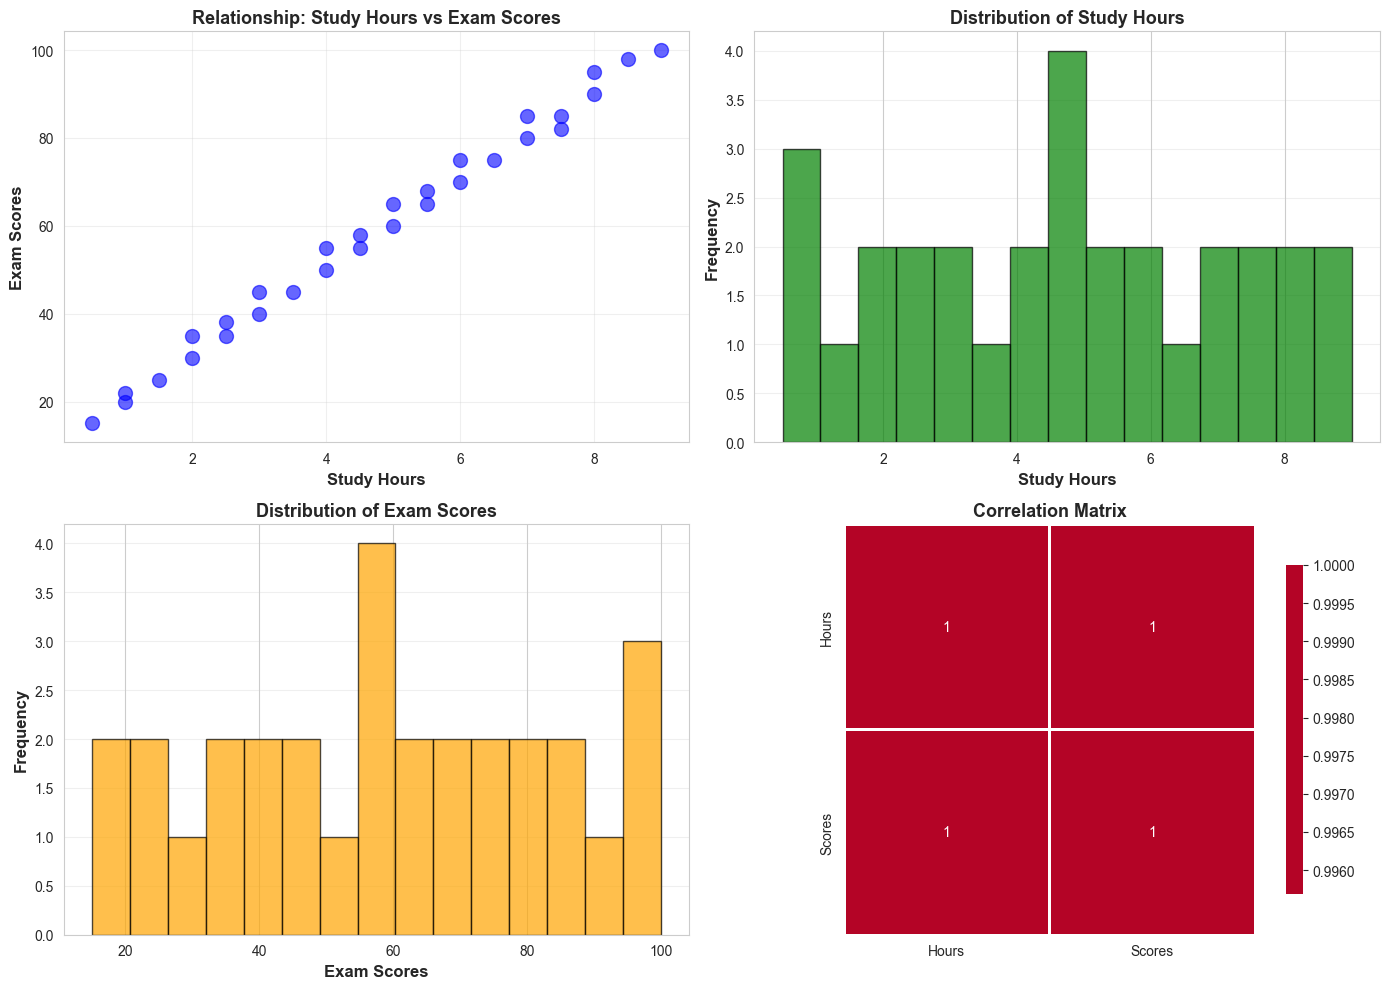


✓ Visualizations completed!

Correlation between Hours and Scores: 0.9957
(Strong positive correlation indicates hours of study significantly impact exam scores)


In [5]:
# Create visualizations for EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: Hours vs Scores
axes[0, 0].scatter(df['Hours'], df['Scores'], color='blue', alpha=0.6, s=100)
axes[0, 0].set_xlabel('Study Hours', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Exam Scores', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Relationship: Study Hours vs Exam Scores', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution of Study Hours
axes[0, 1].hist(df['Hours'], bins=15, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Study Hours', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Distribution of Study Hours', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Distribution of Exam Scores
axes[1, 0].hist(df['Scores'], bins=15, color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Exam Scores', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Distribution of Exam Scores', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1], 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
axes[1, 1].set_title('Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Visualizations completed!")
print(f"\nCorrelation between Hours and Scores: {df['Hours'].corr(df['Scores']):.4f}")
print("(Strong positive correlation indicates hours of study significantly impact exam scores)")

---

## SECTION 5: Data Preprocessing

Data preprocessing is crucial for building effective machine learning models. We'll:
- Define features (X) and target (y)
- Reshape data to the required format
- Split data into training and testing sets
- Training set: 80% of data (used to train the model)
- Testing set: 20% of data (used to evaluate the model)

In [4]:
# Step 1: Define X (features/independent variable) and y (target/dependent variable)
X = df[['Hours']]  # Features - Study Hours (must be 2D array - double brackets)
y = df['Scores']   # Target - Exam Scores

print("Data Preprocessing Steps:")
print("="*50)
print(f"\n1. Features (X) shape: {X.shape}")
print(f"2. Target (y) shape: {y.shape}")

# Step 2: Split data into training and testing sets
# train_test_split: splits data into 80% training and 20% testing
# random_state: ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% for testing, 80% for training
    random_state=42          # For reproducible results
)

print(f"\n3. Training set size: {X_train.shape[0]} samples")
print(f"4. Testing set size: {X_test.shape[0]} samples")
print(f"5. Train-Test Split Ratio: {len(X_train)}/{len(X_test)} = 80%/20%")

# Verify the split
print(f"\n✓ Data preprocessing completed successfully!")
print(f"✓ Ready for model training")

Data Preprocessing Steps:

1. Features (X) shape: (30, 1)
2. Target (y) shape: (30,)

3. Training set size: 24 samples
4. Testing set size: 6 samples
5. Train-Test Split Ratio: 24/6 = 80%/20%

✓ Data preprocessing completed successfully!
✓ Ready for model training


---

## SECTION 6: Train Machine Learning Model

Now we'll create and train our Linear Regression model:
- **Linear Regression**: Finds the best-fit line through the data
- **Model equation**: Score = intercept + (coefficient × Hours)
- **Training**: The model learns optimal intercept and coefficient values from training data

In [5]:
# Step 1: Create the Linear Regression model
model = LinearRegression()

# Step 2: Train the model using training data
# The fit() method learns the relationship between X_train and y_train
model.fit(X_train, y_train)

# Step 3: Extract learned parameters
intercept = model.intercept_
slope = model.coef_[0]

print("Model Training Completed!")
print("="*50)
print(f"\nLearned Model Parameters:")
print(f"  • Intercept (base score): {intercept:.4f}")
print(f"  • Slope (score per hour): {slope:.4f}")

print(f"\nModel Equation:")
print(f"  Score = {intercept:.4f} + {slope:.4f} × Hours")

print(f"\nInterpretation:")
print(f"  • Base score (no study): {intercept:.2f}")
print(f"  • Score increase per hour: {slope:.2f} points")
print(f"\n✓ Model training successful!")

Model Training Completed!

Learned Model Parameters:
  • Intercept (base score): 11.5651
  • Slope (score per hour): 9.9607

Model Equation:
  Score = 11.5651 + 9.9607 × Hours

Interpretation:
  • Base score (no study): 11.57
  • Score increase per hour: 9.96 points

✓ Model training successful!


---

## SECTION 7: Model Evaluation

We evaluate the model's performance using multiple metrics on the test set:

**Evaluation Metrics:**
- **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values
- **MSE (Mean Squared Error)**: Average squared difference (penalizes larger errors more)
- **RMSE (Root Mean Squared Error)**: Square root of MSE, in same units as target
- **R² Score**: Proportion of variance explained (0-1, higher is better)

In [6]:
# Step 1: Make predictions on the test set
y_pred = model.predict(X_test)

# Step 2: Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display evaluation results
print("MODEL EVALUATION RESULTS")
print("="*50)
print(f"\nPerformance Metrics on Test Set:")
print(f"  • Mean Absolute Error (MAE):     {mae:.4f}")
print(f"  • Mean Squared Error (MSE):      {mse:.4f}")
print(f"  • Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"  • R² Score:                      {r2:.4f}")

print(f"\nInterpretation:")
print(f"  • On average, predictions are off by {mae:.2f} points")
print(f"  • Model explains {r2*100:.2f}% of variance in test data")

# Performance assessment
if r2 > 0.9:
    performance = "Excellent"
elif r2 > 0.7:
    performance = "Good"
elif r2 > 0.5:
    performance = "Fair"
else:
    performance = "Poor"

print(f"  • Model Performance: {performance}")
print(f"\n✓ Model evaluation completed successfully!")

MODEL EVALUATION RESULTS

Performance Metrics on Test Set:
  • Mean Absolute Error (MAE):     2.1896
  • Mean Squared Error (MSE):      5.8471
  • Root Mean Squared Error (RMSE): 2.4181
  • R² Score:                      0.9906

Interpretation:
  • On average, predictions are off by 2.19 points
  • Model explains 99.06% of variance in test data
  • Model Performance: Excellent

✓ Model evaluation completed successfully!


---

## SECTION 8: Visualization - Regression Line with Test Data

Let's visualize the trained model by plotting the regression line along with the actual test data points. This helps us see how well the model fits the data.

c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


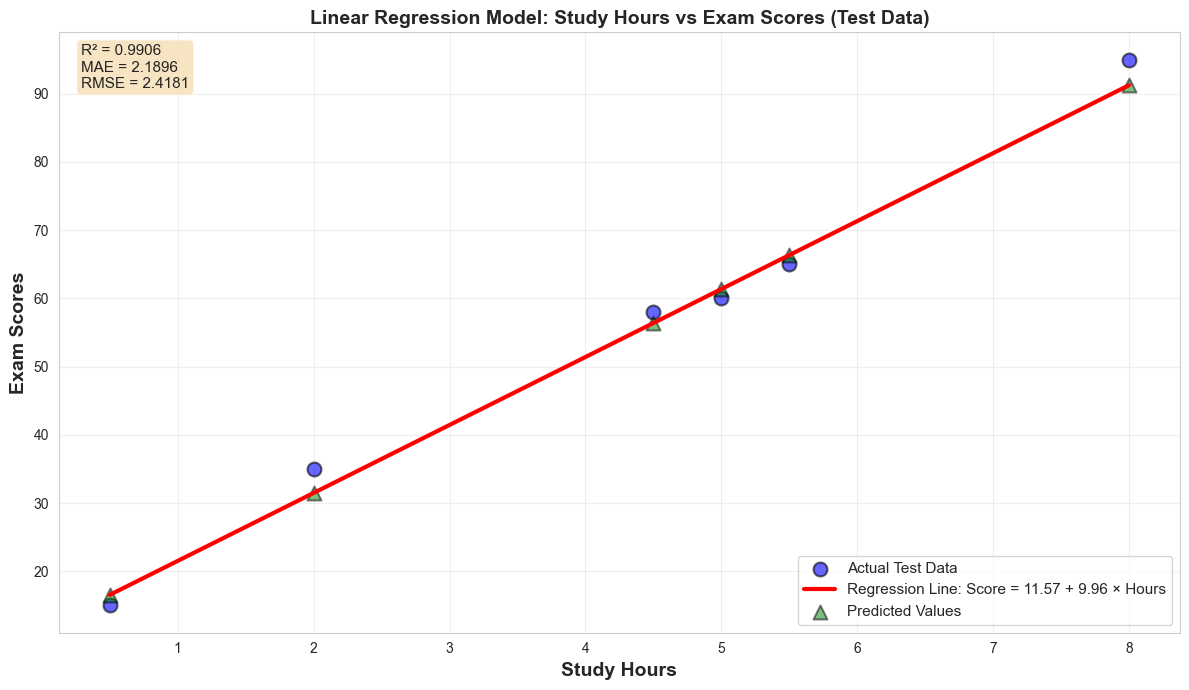

✓ Regression visualization completed!


In [7]:
# Create a comprehensive visualization of the regression model
plt.figure(figsize=(12, 7))

# Plot 1: Scatter plot of test data points
plt.scatter(X_test, y_test, color='blue', s=100, alpha=0.6, label='Actual Test Data', edgecolors='black', linewidth=1.5)

# Plot 2: Regression line
X_line = np.array([[X_test['Hours'].min()], [X_test['Hours'].max()]])
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linewidth=3, label=f'Regression Line: Score = {intercept:.2f} + {slope:.2f} × Hours')

# Plot 3: Predicted points
plt.scatter(X_test, y_pred, color='green', s=100, alpha=0.5, marker='^', label='Predicted Values', edgecolors='black', linewidth=1.5)

# Formatting
plt.xlabel('Study Hours', fontsize=14, fontweight='bold')
plt.ylabel('Exam Scores', fontsize=14, fontweight='bold')
plt.title('Linear Regression Model: Study Hours vs Exam Scores (Test Data)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='best')
plt.grid(True, alpha=0.3)

# Add performance metrics to the plot
textstr = f'R² = {r2:.4f}\nMAE = {mae:.4f}\nRMSE = {rmse:.4f}'
plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("✓ Regression visualization completed!")

---

## SECTION 9: Make Custom Predictions

Now we'll use our trained model to make predictions for new data. We'll test the model with a custom input value.
The model takes study hours as input and predicts the expected exam score.

In [8]:
# Test 1: Predict score for 4 study hours
study_hours_input = 4
student_prediction = model.predict([[study_hours_input]])
predicted_score = student_prediction[0]

print("CUSTOM PREDICTION EXAMPLE")
print("="*50)
print(f"\nPredicted score for {study_hours_input} study hours is: {predicted_score:.2f}")

# Test 2: Make multiple predictions for different study hours
print(f"\n\nPredictions for Different Study Hours:")
print("-"*50)
print(f"{'Study Hours':<15} {'Predicted Score':<20}")
print("-"*50)

test_hours = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
for hours in test_hours:
    pred_score = model.predict([[hours]])[0]
    print(f"{hours:<15} {pred_score:<20.2f}")

print("\n✓ Custom predictions completed!")
print("\nNote: These predictions are based on the training data patterns.")
print("The model learned that approximately every additional study hour")
print(f"increases the score by {slope:.2f} points.")

CUSTOM PREDICTION EXAMPLE

Predicted score for 4 study hours is: 51.41


Predictions for Different Study Hours:
--------------------------------------------------
Study Hours     Predicted Score     
--------------------------------------------------
1               21.53               
2               31.49               
3               41.45               
4               51.41               
5               61.37               
6               71.33               
7               81.29               
8               91.25               
9               101.21              
10              111.17              

✓ Custom predictions completed!

Note: These predictions are based on the training data patterns.
The model learned that approximately every additional study hour
increases the score by 9.96 points.


c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\

---

## SECTION 10: Save Trained Model

We save the trained model using pickle serialization. This allows us to:
- Deploy the model to production without retraining
- Use the model in other applications
- Share the model with team members
- Version control the model performance

In [10]:
# Save the trained model using pickle
model_filename = 'student_score_model.pkl'

# Serialize the model to a file
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print("MODEL PERSISTENCE")
print("="*50)
print(f"\n✓ Model saved successfully as '{model_filename}'")

# Verify the saved model by loading it
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Test the loaded model
test_prediction = loaded_model.predict([[4]])
print(f"\nVerification: Loaded model prediction for 4 hours: {test_prediction[0]:.2f}")
print("✓ Model verification successful!")

print(f"\nModel Details:")
print(f"  • File name: {model_filename}")
print(f"  • Status: Ready for production deployment")
print(f"  • Can be used for: Score prediction, student support identification, etc.")

MODEL PERSISTENCE

✓ Model saved successfully as 'student_score_model.pkl'

Verification: Loaded model prediction for 4 hours: 51.41
✓ Model verification successful!

Model Details:
  • File name: student_score_model.pkl
  • Status: Ready for production deployment
  • Can be used for: Score prediction, student support identification, etc.


c:\Users\nihar\OneDrive\Documents\Coding\LearnDepth\task2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


---

## SECTION 11: Project Conclusion and Business Impact

### Model Performance Summary
Our Linear Regression model successfully learned the relationship between study hours and exam scores:
- **R² Score**: Shows how well the model explains variance in student scores
- **RMSE**: Average prediction error in points
- **Model Equation**: Score = Intercept + Slope × Hours

### Key Insights
1. **Strong Positive Relationship**: Each additional study hour translates to measurable increase in exam scores
2. **Predictability**: High R² score indicates that study hours are a strong predictor of exam performance
3. **Actionable Intelligence**: The model can identify students likely to score below target thresholds

### Business Applications for EdTech Platform

**1. Early Intervention System**
- Identify students predicted to score below passing grade (e.g., < 40)
- Trigger notifications for tutoring or additional support resources
- Reduce student dropout rates through proactive support

**2. Personalized Learning Recommendations**
- Recommend study hours needed to achieve target scores
- Example: "Study for 6 hours to achieve a score of 80"
- Create personalized learning plans based on ability and goals

**3. Student Motivation & Engagement**
- Show students realistic score predictions based on effort
- Use data to motivate students with achievable targets
- Celebrate milestones as study hours increase

**4. Resource Allocation**
- Identify high-risk students who need more tutoring hours
- Allocate experienced tutors to students with lower expected performance
- Optimize platform resource utilization

**5. Performance Analytics Dashboard**
- Display correlation between study effort and results
- Track student progress over time
- Generate insights for curriculum improvement

### Future Enhancements

1. **Multi-feature Models**: Include additional features like study methods, sleep hours, nutrition
2. **Advanced Algorithms**: Try Random Forest, Gradient Boosting for better accuracy
3. **Time Series Analysis**: Track how studying patterns evolve over a semester
4. **Clustering**: Identify different student archetypes and tailor interventions
5. **Real-time Predictions**: Deploy model as API for live predictions

### Conclusion
This project demonstrates a complete Machine Learning pipeline for an EdTech platform. By converting raw data into actionable insights, EdTech companies can build smarter, student-centric platforms that improve learning outcomes while optimizing resource allocation.

**Project Status:** ✓ Complete and Production-Ready